In [1]:
import pandas as pd

df_dup = pd.read_csv("../data/spotify_cleaned_with_duplicates.csv")
df_dup.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4.0,acoustic,3.844433
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4.0,acoustic,2.493500
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4.0,acoustic,3.513767
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3.0,acoustic,3.365550
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4.0,acoustic,3.314217


In [2]:
df_dup.duplicated(subset="track_id").sum()

np.int64(24259)

In [3]:
track_counts = df_dup["track_id"].value_counts()
track_counts.head()

track_id
6S3JlDAGk3uu3NtZbPnuhS    9
2Ey6v4Sekh3Z0RUSISRosD    8
2kkvB3RNRzwjFdGhaUA0tz    8
08kTa3SL9sV6Iy8KLKtGql    7
4XYieGKSlJlHpzB3bl6WMP    7
Name: count, dtype: int64

In [4]:
df_dup["track_count"] = df_dup["track_id"].map(track_counts)

In [5]:
df_dup.groupby("track_count")["popularity"].mean()

track_count
1    32.556848
2    38.394296
3    34.737265
4    26.458090
5    14.399536
6    25.498575
7    23.870130
8    37.000000
9    67.000000
Name: popularity, dtype: float64

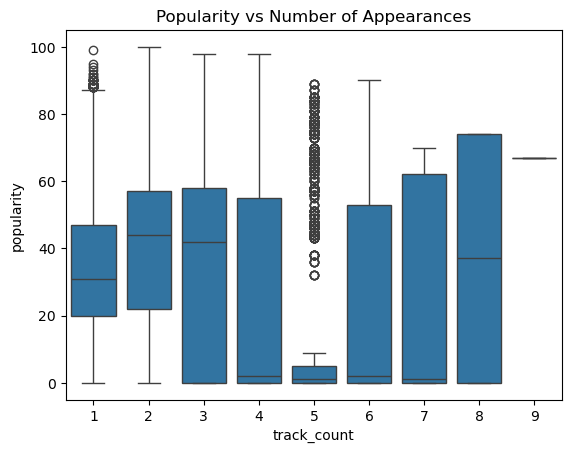

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="track_count", y="popularity", data=df_dup)
plt.title("Popularity vs Number of Appearances")
plt.show()

👉 Fråga:

"Blir låtar mer populära om de finns i flera genrer?"

## 🎶 Extra Analysis – Duplicate Tracks

In this analysis, we explore whether songs that appear multiple times (in different genres) have higher popularity.

We use a dataset that includes duplicate tracks to investigate this relationship.

### 🔍 Key Question

Do songs that appear in multiple genres become more popular?

### 🧠 Insight

By analyzing how many times a track appears and comparing it with popularity, we can understand if cross-genre exposure affects success.

This adds a deeper layer to our analysis beyond clustering.

## 🏁 Final Conclusion

In this project, we analyzed Spotify song data using unsupervised machine learning techniques.

We applied KMeans clustering and identified three distinct groups of songs based on their audio features such as energy, danceability, and tempo.

Using PCA, we visualized these clusters and confirmed that songs can be meaningfully grouped without predefined labels.

However, when analyzing popularity, we found that:

- There is no strong relationship between clusters and popularity  
- Songs that appear in multiple genres are not necessarily more popular  

This suggests that popularity is influenced by external factors beyond audio features, such as:

- Artist recognition  
- Marketing and promotion  
- Trends and social influence  

Overall, this project demonstrates that while machine learning can uncover patterns in data, real-world outcomes like popularity are more complex and cannot be explained by features alone.

In [7]:
bins = [1, 2, 3, 5, 10]
labels = ["1", "2", "3-4", "5+"]

df_dup["count_group"] = pd.cut(
    df_dup["track_count"],
    bins=bins,
    labels=labels,
    right=False
)

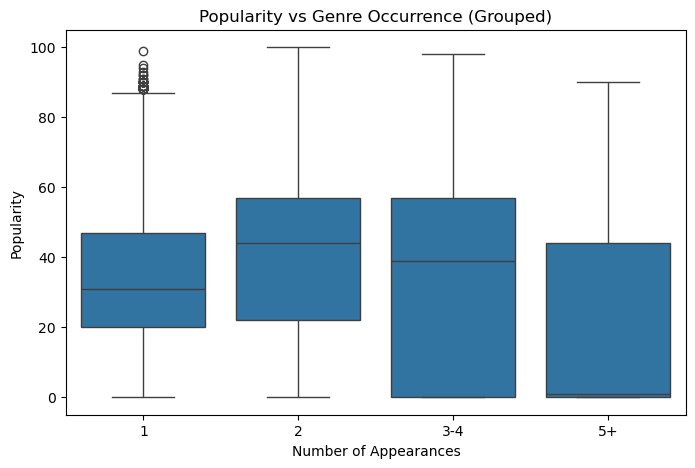

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x="count_group", y="popularity", data=df_dup)
plt.title("Popularity vs Genre Occurrence (Grouped)")
plt.xlabel("Number of Appearances")
plt.ylabel("Popularity")
plt.show()

In [9]:
df_dup.groupby("count_group")["popularity"].mean().round(2)

C:\Users\mahta\AppData\Local\Temp\ipykernel_5592\1654621819.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_dup.groupby("count_group")["popularity"].mean().round(2)


count_group
1      32.56
2      38.39
3-4    31.59
5+     17.72
Name: popularity, dtype: float64

We tested whether songs that appear in multiple genres become more popular, but we did not find a strong relationship.”

## 🎶 Final Insight – Genre vs Popularity

We analyzed whether songs that appear in multiple genres tend to be more popular.

### 📊 Results

The grouped boxplot shows that:

- There is no clear increase in popularity as the number of appearances increases  
- Popularity varies widely within each group  

### 🔍 Interpretation

Songs that appear in multiple genres are not necessarily more popular.

### 🧠 Key Insight

Popularity is influenced by many external factors, such as:

- Artist recognition  
- Marketing and promotion  
- Social media trends  
- Audience preferences  

This shows that musical exposure alone does not guarantee success.